In [ ]:
import pandas as pd

In [ ]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name,lenght
0,25.4,242.0,apple,NaN
1,26.3,290.0,apple,NaN
2,26.5,340.0,apple,NaN
3,29.0,363.0,apple,NaN
4,29.0,430.0,apple,NaN


> fruits는 35개의 apple과 14의 berry로 정렬 및 구성

In [ ]:
fruits.iloc[:35,:]

,length,weight,name,lenght
0,25.4,242.0,apple,NaN
1,26.3,290.0,apple,NaN
2,26.5,340.0,apple,NaN
3,29.0,363.0,apple,NaN
4,29.0,430.0,apple,NaN
5,29.7,450.0,apple,NaN
6,29.7,500.0,apple,NaN
7,30.0,390.0,apple,NaN
8,30.0,450.0,apple,NaN
9,30.7,500.0,apple,NaN


In [ ]:
# apple 정보 불러오기
apple = fruits.iloc[:35,:]
apple.tail()

,length,weight,name,lenght
30,38.5,920.0,apple,NaN
31,38.5,955.0,apple,NaN
32,39.5,925.0,apple,NaN
33,41.0,975.0,apple,NaN
34,41.0,950.0,apple,NaN


In [ ]:
# 산포도로 확인하기
import matplotlib.pylab as plt

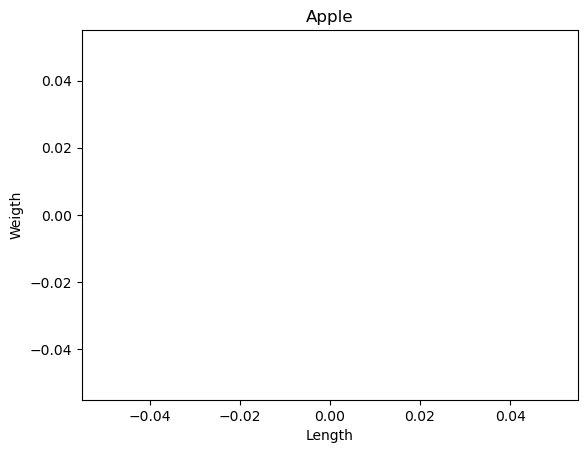

In [ ]:
plt.scatter(
    apple.lenght,
    apple.weight
)

plt.xlabel("Length")
plt.ylabel("Weigth")
plt.title("Apple")
plt.show()


In [ ]:
# berry 불러오기

berry = fruits.iloc[35:,:]
berry.tail()

,length,weight,name,lenght
44,NaN,12.2,berry,12.2
45,NaN,13.4,berry,12.4
46,NaN,12.2,berry,13.0
47,NaN,19.7,berry,14.3
48,NaN,19.9,berry,15.0


Text(0.5, 1.0, 'Berry')

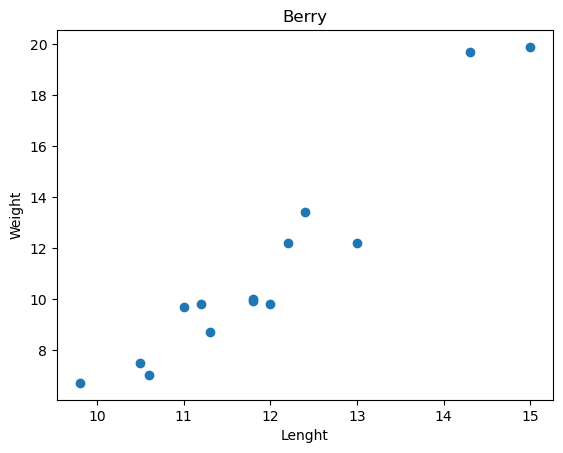

In [ ]:
plt.scatter(
    berry.lenght,
    berry.weight
)

plt.xlabel("Lenght")
plt.ylabel("Weight")
plt.title("Berry")

In [57]:
# berry 불러오기 _선생님 정답

berry = fruits.iloc[35:,:]
berry.head()

,length,weight,name,lenght
35,NaN,6.7,berry,9.8
36,NaN,7.5,berry,10.5
37,NaN,7.0,berry,10.6
38,NaN,9.7,berry,11.0
39,NaN,9.8,berry,11.2


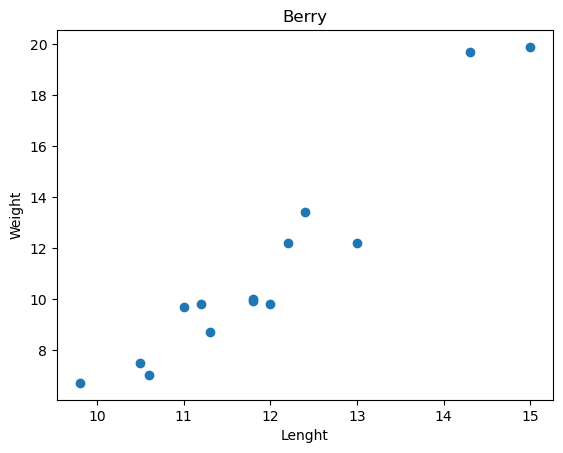

In [58]:
plt.scatter(
    berry.lenght,
    berry.weight
)

plt.xlabel("Lenght")
plt.ylabel("Weight")
plt.title("Berry")

plt.show()

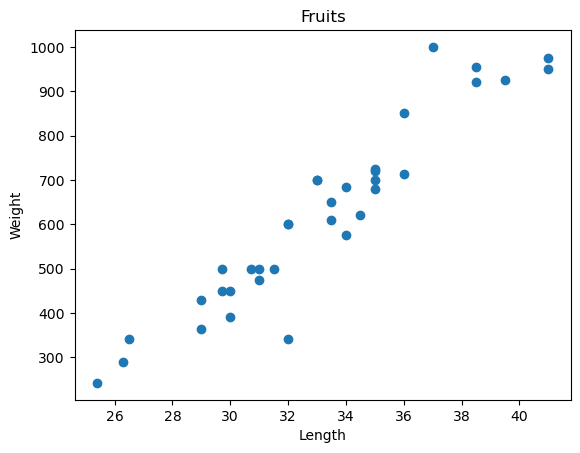

In [74]:
# fruits로 산포도
plt.scatter(
    fruits.length,
    fruits.weight
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Fruits")

plt.show()

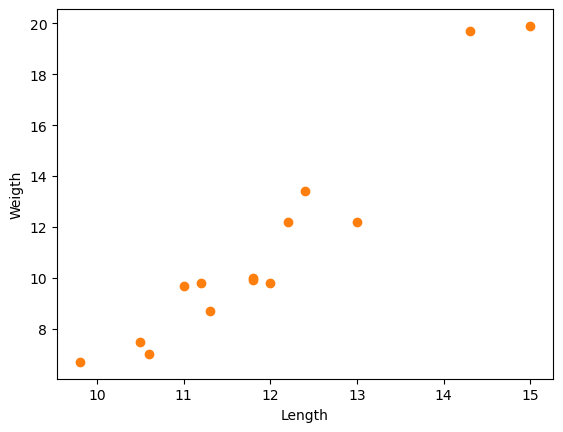

In [60]:
# 2개의 Dataset을 산포도로 한꺼번에 비교하기

plt.scatter(
    apple.lenght,
    apple.weight
)

plt.scatter(
    berry.lenght,
    berry.weight
)
plt.xlabel("Length")
plt.ylabel("Weigth")


plt.show()

---
### 머신러닝을 위한 데이터 준비
- Feature Data 와 Target Data의 분리

In [67]:
# Feature Data

# freatureColumns = ['lenght', 'weight']
# fruitsData = [freatureColumns]
fruitsData = fruits.loc[:,['length','weight']]
fruitsData.head()


,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [68]:
# Target Data

fruitsTarget = fruits.name
fruitsTarget[:5]

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [69]:
fruitsTarget.info()

<class 'pandas.core.series.Series'>
RangeIndex: 49 entries, 0 to 48
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
49 non-null     object
dtypes: object(1)
memory usage: 524.0+ bytes


### 최근접 이웃(kNN:k  Nearest Neighbors) 분류 알고리즘 사용 

In [70]:
from sklearn.neighbors import KNeighborsClassifier

In [71]:
# Model 생성

kn = KNeighborsClassifier() # n_neighbors=5 <= default 

In [72]:
# 학습 시키기

kn.fit(fruitsData,fruitsTarget)

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# 정확도

kn.score(fruitsData, fruitsTarget)

1.0

In [ ]:
# 워닝 제거
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 예측해 보기
# 길이가 30cm이고 무게가 600g인 것은 무엇인가?
# 내가 한 정답
kn.predict([[30, 600]])

array(['apple'], dtype=object)

In [ ]:
# 예측해 보기
# 길이가 30cm이고 무게가 600g인 것은 무엇인가?
# 선생님 정답 // 2차원데이터라 대괄호 두개 -> 내가 한 정답에 글자만 줄거라 뒤에 붙인 것임
kn.predict([[30, 600]])[0]

'apple'

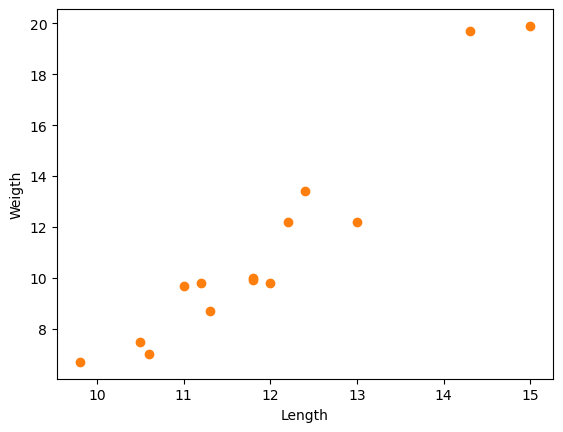

In [ ]:
# 산포도 예측 범위 확인하기

plt.scatter(
    apple.lenght,
    apple.weight
)


plt.scatter(
    berry.lenght,
    berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weigth')

plt.show()